In [1]:
import numpy as np
import torch 
import itertools
import pandas as pd
import matplotlib.pyplot as plt
from anastruct import SystemElements
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt 
import openpyxl as pxl
import torch.nn.functional as F
import os
import re
import csv
from datetime import datetime
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics  import mean_absolute_error, r2_score


In [2]:
#General Parameters

dropout    = 0.1   # Neuron deactivation (0 = off for small datasets)
epochs     = 800    # increased: force model had more to give
seed       = 42
patience   = 50    # increased: allow more time before early stop
batch_size = 32


In [3]:
#import Excel Data

notebook_dir = os.getcwd()
file_path = os.path.join(notebook_dir, 'Data', 'MLPartAB4.xlsx')

#read Excel with data values only
wb_data = pxl.load_workbook(file_path, data_only=True)
ws_data = wb_data.active
headers = [ws_data.cell(1, col).value for col in range(1, ws_data.max_column + 1)]
data    = [row for row in ws_data.iter_rows(min_row=2, values_only=True)]

df_training = pd.DataFrame(data, columns=headers)
df_training = df_training.drop(columns=[None], errors='ignore').dropna().reset_index(drop=True)
print(f"df_training shape: {df_training.shape}")


df_training shape: (796, 20)


In [4]:
# Verify 
# ── 8. Verify against Excel ───────────────────────────────────
print(f"\n{'='*60}")
print(f"  Verify — Python vs Excel (row 1)")
print(f"{'='*60}")
print(f"{'Column':>15} | {'Excel':>12} | {'Python':>12} | {'Match':>6}")
print(f"{'-'*60}")


# ── 9. Final dataset summary ──────────────────────────────────
print(f"\n{'='*60}")
print(f"  FINAL DATASET")
print(f"{'='*60}")
print(f"  Shape   : {df_training.shape}")
print(f"  Columns : {df_training.columns.tolist()}")
print(f"\n{'='*60}")
print(f"  STATISTICS")
print(f"{'='*60}")
print(f"{'Column':>15} | {'Min':>12} | {'Max':>12} | {'Mean':>12}")
print(f"{'-'*60}")
for col in df_training.columns:
    vals = df_training[col].dropna()
    if vals.dtype in [float, int]:
        print(f"{col:>15} | {vals.min():>12.4f} | "
              f"{vals.max():>12.4f} | {vals.mean():>12.4f}")
print(f"{'='*60}")


  Verify — Python vs Excel (row 1)
         Column |        Excel |       Python |  Match
------------------------------------------------------------

  FINAL DATASET
  Shape   : (796, 20)
  Columns : ['r (m)', 'e (m)', 'L (m)', 'Ac (m²)', 'Ar (m²)', 'RPM', 'QRR', 'Torque', 'P_input', 'Fbox (N)', 'width (m)', 'height (m)', 'pin_dia (m)', '|RT0|max', '|P1|max', '|B0|max', 'FOS', 'N_to', 'N_Bo', 'N_P1']

  STATISTICS
         Column |          Min |          Max |         Mean
------------------------------------------------------------
          r (m) |       0.0440 |       0.1994 |       0.1274
          e (m) |       0.0100 |       0.0500 |       0.0304
          L (m) |       0.2554 |       1.1774 |       0.5769
        Ac (m²) |       0.0001 |       0.0010 |       0.0006
        Ar (m²) |       0.0001 |       0.0010 |       0.0006
            RPM |      15.0355 |      44.9652 |      30.1682
            QRR |       1.0021 |       1.0722 |       1.0198
         Torque |       0.1301

In [5]:
# ── Target column definitions ──────────────────────────────────────────────────
input_col = ['r (m)', 'e (m)', 'L (m)', 'Ac (m²)', 'Ar (m²)', 'RPM', 'QRR','width (m)', 'height (m)', 'pin_dia (m)','FOS','Fbox (N)']
force_cols   = ['|RT0|max', '|P1|max', '|B0|max','Torque','P_input']
fatigue_cols = ['N_to', 'N_Bo', 'N_P1']   # already log10 from Excel

target_col = force_cols + fatigue_cols
n_force    = len(force_cols)    # 5
n_fatigue  = len(fatigue_cols)  # 3
n_output   = len(target_col)    # 8
n_input    = len(input_col)     # 12

Yf = df_training[force_cols].copy()
Ya = df_training[fatigue_cols].copy()   # already log10 from Excel
Y  = df_training[target_col].copy()
X  = df_training[input_col].copy()

feature_cols = list(X.columns)

assert np.isfinite(Ya.values).all(), \
    f"Non-finite values in Ya — check log10 columns in Excel. " \
    f"Inf count: {np.isinf(Ya.values).sum()}"

x  = torch.tensor(X.values,  dtype=torch.float32)
yf = torch.tensor(Yf.values, dtype=torch.float32)
ya = torch.tensor(Ya.values, dtype=torch.float32)
y  = torch.tensor(Y.values,  dtype=torch.float32)

print(f"  Dataframe ")
print(f"\n  Yf — Force targets  (stage 1)  : {Yf.shape}")
print(f"       {Yf.columns.tolist()}")
print(f"\n  Ya — Fatigue targets (stage 2) : {Ya.shape}")
print(f"       {Ya.columns.tolist()}")
print(f"\n  X  — Features                  : {X.shape}")
print(f"       {X.columns.tolist()}")
print()
print(f"  x  tensor : {x.shape}   NaN: {torch.isnan(x).sum().item()}")
print(f"  yf tensor : {yf.shape}  NaN: {torch.isnan(yf).sum().item()}")
print(f"  ya tensor : {ya.shape}  NaN: {torch.isnan(ya).sum().item()}")
print(f"\n  ya range  : min={ya.min().item():.3f}  max={ya.max().item():.3f}")


  Dataframe 

  Yf — Force targets  (stage 1)  : (796, 5)
       ['|RT0|max', '|P1|max', '|B0|max', 'Torque', 'P_input']

  Ya — Fatigue targets (stage 2) : (796, 3)
       ['N_to', 'N_Bo', 'N_P1']

  X  — Features                  : (796, 12)
       ['r (m)', 'e (m)', 'L (m)', 'Ac (m²)', 'Ar (m²)', 'RPM', 'QRR', 'width (m)', 'height (m)', 'pin_dia (m)', 'FOS', 'Fbox (N)']

  x  tensor : torch.Size([796, 12])   NaN: 0
  yf tensor : torch.Size([796, 5])  NaN: 0
  ya tensor : torch.Size([796, 3])  NaN: 0

  ya range  : min=6.886  max=49.405


  |r| = 0.991  :  Ar (m²)  ↔  width (m)
  |r| = 0.991  :  Ar (m²)  ↔  height (m)
  |r| = 1.000  :  width (m)  ↔  height (m)


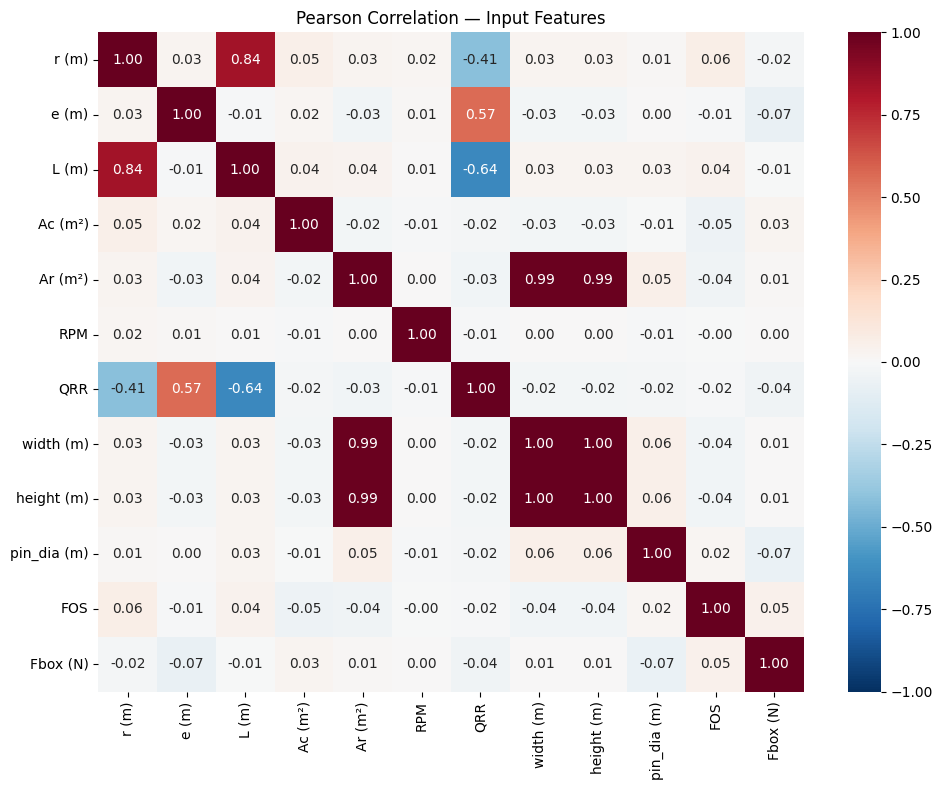

In [6]:
import seaborn as sns

corr = df_training[input_col].corr(method='pearson')

# Flag high-correlation pairs
threshold = 0.85
for i in range(len(input_col)):
    for j in range(i+1, len(input_col)):
        r = corr.iloc[i, j]
        if abs(r) > threshold:
            print(f"  |r| = {abs(r):.3f}  :  {input_col[i]}  ↔  {input_col[j]}")

# Visualize
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, vmin=-1, vmax=1)
plt.title('Pearson Correlation — Input Features')
plt.tight_layout()
plt.show()

In [7]:
#Parameters

num_workers=0   # cpu (AI Recommended)

class Training(Dataset):

    def __init__(self, x_data, yf_data, ya_data):
        assert x_data.shape[0] == yf_data.shape[0] == ya_data.shape[0]
        self.x_data  = x_data
        self.yf_data = yf_data
        self.ya_data = ya_data

    def __len__(self): return self.x_data.shape[0]
    def __getitem__(self, idx):
        return (self.x_data[idx], self.yf_data[idx], self.ya_data[idx])

class Validation(Dataset):
    def __init__(self, x, yf, ya):
        assert x.shape[0] == yf.shape[0] == ya.shape[0]
        self.x  = x
        self.yf = yf
        self.ya = ya

    def __len__(self): return self.x.shape[0]
    def __getitem__(self, idx): return self.x[idx], self.yf[idx], self.ya[idx]


class FatigueLoss(nn.Module):
    def __init__(self, delta=0.5, overpredict_weight=1.5):
        super().__init__()
        self.delta = delta
        self.w_over = overpredict_weight

    def forward(self, pred, target):
        error = pred - target
        abs_error = error.abs()

        # Huber: quadratic below delta, linear above
        quadratic = 0.5 * error ** 2
        linear    = self.delta * (abs_error - 0.5 * self.delta)
        huber     = torch.where(abs_error <= self.delta, quadratic, linear)

        # Asymmetric weight: pred > target = overprediction = dangerous
        weight = torch.where(error > 0,
                             self.w_over,
                             1.0)

        return (weight * huber).mean()


In [8]:
from sklearn.model_selection import train_test_split

def split_data(x, yf, ya, seed, train_frac=0.70, val_frac=0.15):
    n = len(x)
    test_frac = 1.0 - train_frac - val_frac

    # Stratify on FOS if available, otherwise bin primary force output
    fos_col_idx = None
    if 'FOS' in feature_cols:
        fos_col_idx = feature_cols.index('FOS')

    if fos_col_idx is not None:
        strata = x[:, fos_col_idx].numpy()
    else:
        # Bin the first force target into quantiles
        vals = yf[:, 0].numpy()
        strata = np.digitize(vals, np.percentile(vals, np.linspace(0, 100, 6)[1:-1]))

    indices = np.arange(n)

    # Split 1: train vs (val+test)
    train_idx, valtest_idx = train_test_split(
        indices, test_size=val_frac + test_frac,
        stratify=strata, random_state=seed)

    # Split 2: val vs test
    relative_test = test_frac / (val_frac + test_frac)
    valtest_strata = strata[valtest_idx]
    val_idx, test_idx = train_test_split(
        valtest_idx, test_size=relative_test,
        stratify=valtest_strata, random_state=seed)

    return (torch.tensor(train_idx), torch.tensor(val_idx),
            torch.tensor(test_idx))

train_idx, val_idx, test_idx = split_data(x, yf, ya, seed)


In [9]:
class Sohoite_Force(nn.Module):
    def __init__(self, input_dim, n_force=n_force, dropout=dropout):
        super().__init__()
        self.hidden1 = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.hidden2 = nn.Sequential(
            nn.Linear(64, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.heads = nn.ModuleList([nn.Linear(128, 1) for _ in range(n_force)])
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        h1 = self.hidden1(x)
        h2 = self.hidden2(h1)
        return torch.cat([head(h2) for head in self.heads], dim=1)
    
""""
Notes from PyTorch Documentation and Class 
- Linear is the based feature of any code 
- LayerNorm: normalizes the values, and works better for small batches but also of any sizes. It is slow compared to BatchNorm 
- Relu: This is the activation function recommended by Dr. Ince
- Dropout: is a strategy to disable a neuron during training for reductancy. It can also be set at zero

Before starting, the code has to initialize the weights. Based on PyTorch Documentation recommends to use Xavier rather than nn.Linear since it was developed for Sigmoid
""" 

'"\nNotes from PyTorch Documentation and Class \n- Linear is the based feature of any code \n- LayerNorm: normalizes the values, and works better for small batches but also of any sizes. It is slow compared to BatchNorm \n- Relu: This is the activation function recommended by Dr. Ince\n- Dropout: is a strategy to disable a neuron during training for reductancy. It can also be set at zero\n\nBefore starting, the code has to initialize the weights. Based on PyTorch Documentation recommends to use Xavier rather than nn.Linear since it was developed for Sigmoid\n'

In [10]:
class Sohoite_Fatigue(nn.Module):
    def __init__(self, input_dim, n_force=n_force, n_fatigue=n_fatigue, dropout=dropout):
        super().__init__()
        combined_dim = input_dim + n_force

        self.hidden1 = nn.Sequential(
            nn.Linear(combined_dim, 32),
            nn.LayerNorm(32),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.hidden2 = nn.Sequential(
            nn.Linear(32, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.skip = nn.Linear(combined_dim, 64)
        self.heads = nn.ModuleList([nn.Linear(64, 1) for _ in range(n_fatigue)])
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x, Force_P):
        combined = torch.cat([x, Force_P], dim=1)
        h1 = self.hidden1(combined)
        h2 = self.hidden2(h1)
        h2 = h2 + self.skip(combined)
        return torch.cat([head(h2) for head in self.heads], dim=1)









In [11]:
# Functions

def train_force_epoch(force_model, loader, optimizer, device,
                      x_mean, x_std, yf_mean, yf_std):
    force_model.train()
    criterion  = nn.MSELoss()
    total_loss = 0.0

    for x_batch, yf_batch, _ in loader:
        x_batch  = x_batch.to(device)
        yf_batch = yf_batch.to(device)

        optimizer.zero_grad()
        pred_forces = force_model(x_batch)
        loss = criterion(pred_forces, yf_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(force_model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(x_batch)

    return total_loss / len(loader.dataset)


def train_fatigue_epoch(force_model, fatigue_model, loader, optimizer, device,
                        x_mean, x_std, yf_mean, yf_std, ya_mean, ya_std):
    force_model.eval()
    fatigue_model.train()
    criterion  = FatigueLoss(delta=0.5, overpredict_weight=1.5)
    total_loss = 0.0

    for x_batch, _, ya_batch in loader:
        x_batch  = x_batch.to(device)
        ya_batch = ya_batch.to(device)

        optimizer.zero_grad()
        with torch.no_grad():
            pred_forces = force_model(x_batch)

        pred_fatigue = fatigue_model(x_batch, pred_forces)
        loss = criterion(pred_fatigue, ya_batch)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(fatigue_model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(x_batch)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate_force(force_model, loader, device):
    force_model.eval()
    criterion  = nn.MSELoss()
    total_loss = 0.0
    all_pf, all_tf = [], []

    for x_batch, yf_batch, _ in loader:   # Validation now yields 3 items
        x_batch  = x_batch.to(device)
        yf_batch = yf_batch.to(device)

        pred_f = force_model(x_batch)
        total_loss += criterion(pred_f, yf_batch).item() * len(x_batch)
        all_pf.append(pred_f.cpu())
        all_tf.append(yf_batch.cpu())

    return (
        total_loss / len(loader.dataset),
        torch.cat(all_pf), torch.cat(all_tf),
    )


@torch.no_grad()
def evaluate_fatigue(force_model, fatigue_model, loader, device):
    force_model.eval()
    fatigue_model.eval()
    criterion  = nn.MSELoss()
    total_loss = 0.0
    all_pa, all_ta = [], []

    for x_batch, _, ya_batch in loader:   # Validation now yields 3 items
        x_batch  = x_batch.to(device)
        ya_batch = ya_batch.to(device)

        pred_f  = force_model(x_batch)               # cascade
        pred_fa = fatigue_model(x_batch, pred_f)
        total_loss += criterion(pred_fa, ya_batch).item() * len(x_batch)
        all_pa.append(pred_fa.cpu())
        all_ta.append(ya_batch.cpu())

    return (
        total_loss / len(loader.dataset),
        torch.cat(all_pa), torch.cat(all_ta),
    )


def tester_force(y_pred_norm, y_true_norm, y_mean, y_std, cols):
    """Denormalize: z-score → log space → real Newtons via expm1."""
    y_pred_log = y_pred_norm * y_std + y_mean
    y_true_log = y_true_norm * y_std + y_mean
    y_pred = torch.expm1(y_pred_log).numpy()    # inverse of log1p
    y_true = torch.expm1(y_true_log).numpy()
    results = {}
    for i, col in enumerate(cols):
        err    = y_pred[:, i] - y_true[:, i]
        mae    = float(np.mean(np.abs(err)))
        rmse   = float(np.sqrt(np.mean(err ** 2)))
        ss_res = np.sum(err ** 2)
        ss_tot = np.sum((y_true[:, i] - y_true[:, i].mean()) ** 2)
        r2     = float(1 - ss_res / (ss_tot + 1e-8))
        results[col] = {'mae': mae, 'rmse': rmse, 'r2': r2}
    mean_mae = float(np.mean([v['mae'] for v in results.values()]))
    return results, mean_mae


def tester_fatigue(y_pred_norm, y_true_norm, y_mean, y_std, cols):
    """Fatigue is already log10 from Excel — just undo z-score, no expm1."""
    y_pred = (y_pred_norm * y_std + y_mean).numpy()
    y_true = (y_true_norm * y_std + y_mean).numpy()
    results = {}
    for i, col in enumerate(cols):
        err    = y_pred[:, i] - y_true[:, i]
        mae    = float(np.mean(np.abs(err)))
        rmse   = float(np.sqrt(np.mean(err ** 2)))
        ss_res = np.sum(err ** 2)
        ss_tot = np.sum((y_true[:, i] - y_true[:, i].mean()) ** 2)
        r2     = float(1 - ss_res / (ss_tot + 1e-8))
        results[col] = {'mae': mae, 'rmse': rmse, 'r2': r2}
    mean_mae = float(np.mean([v['mae'] for v in results.values()]))
    return results, mean_mae


In [12]:

device = torch.device(
    'mps'  if torch.backends.mps.is_available()  else
    'cuda' if torch.cuda.is_available()          else
    'cpu'
) # AI recommended 


In [13]:
# Set Up
x_tr  = x[train_idx];  yf_tr  = yf[train_idx];   ya_tr = ya[train_idx]
x_val = x[val_idx];    yf_val = yf[val_idx];      ya_val = ya[val_idx]
x_te  = x[test_idx];   yf_te  = yf[test_idx];      ya_te = ya[test_idx]

# ── Log-transform forces (compresses range so small & large forces matter equally) ──
yf_tr_log  = torch.log1p(yf_tr)      # log(1 + F), safe for small values
yf_val_log = torch.log1p(yf_val)
yf_te_log  = torch.log1p(yf_te)

# ── Normalize inputs ──
x_mean = x_tr.mean(dim=0)
x_std  = x_tr.std(dim=0).clamp(min=1e-8)

# ── Normalize LOG forces (not raw forces) ──
yf_mean = yf_tr_log.mean(dim=0)
yf_std  = yf_tr_log.std(dim=0).clamp(min=1e-8)

# ── Normalize fatigue (unchanged — already log10 from Excel) ──
ya_mean = ya_tr.mean(dim=0)
ya_std  = ya_tr.std(dim=0).clamp(min=1e-8)

x_tr_norm  = (x_tr  - x_mean) / x_std
x_val_norm = (x_val - x_mean) / x_std
x_te_norm  = (x_te  - x_mean) / x_std
yf_tr_norm  = (yf_tr_log  - yf_mean) / yf_std    # normalized LOG forces
yf_val_norm = (yf_val_log - yf_mean) / yf_std
yf_te_norm  = (yf_te_log  - yf_mean) / yf_std
ya_tr_norm  = (ya_tr  - ya_mean) / ya_std
ya_val_norm = (ya_val - ya_mean) / ya_std
ya_te_norm  = (ya_te  - ya_mean) / ya_std


# Define static datasets (val and test never change)
val_ds  = Validation(x_val_norm, yf_val_norm, ya_val_norm)
test_ds = Validation(x_te_norm,  yf_te_norm,  ya_te_norm)

val_loader  = DataLoader(val_ds,  batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)

# Two Stage Models
force_model   = Sohoite_Force(input_dim=x.shape[1]).to(device)
fatigue_model = Sohoite_Fatigue(input_dim=x.shape[1]).to(device)

# ── Stage 1 — ForceNet (no mixup) ────────────────────────────────
optimizer_force = optim.AdamW(force_model.parameters(),
                              lr=1e-4, weight_decay=5e-3)

best_force_val    = float('inf')
best_force_state  = None
epochs_no_improve = 0
stopped_force     = epochs
force_train_hist  = []
force_val_hist    = []

# Build dataset once from real data — no mixup
train_ds     = Training(x_tr_norm, yf_tr_norm, ya_tr_norm)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                          drop_last=True, num_workers=0,
                          generator=torch.Generator().manual_seed(seed))

print("  Stage 1 — ForceNet (log-transformed, no mixup)")
print(f'  {"Epoch":>6} | {"Train Loss":>12} | {"Val Loss":>10} |')
print(f'  {"-"*40}')

for epoch in range(1, epochs + 1):
    tr_loss        = train_force_epoch(force_model, train_loader, optimizer_force,
                                       device, x_mean, x_std, yf_mean, yf_std)
    val_loss, _, _ = evaluate_force(force_model, val_loader, device)

    force_train_hist.append(tr_loss)
    force_val_hist.append(val_loss)

    if val_loss < best_force_val:
        best_force_val   = val_loss
        best_force_state = {k: v.clone() for k, v in force_model.state_dict().items()}
        epochs_no_improve = 0
        mark = '*'
    else:
        epochs_no_improve += 1
        mark = ' '

    if epoch % 50 == 0 or epoch == 1:
        print(f'  {epoch:>6} | {tr_loss:>12.6f} | {val_loss:>10.6f} | {mark}')

    if epochs_no_improve >= patience:
        stopped_force = epoch
        break

print(f'\n  Stopped : epoch {stopped_force}  |  Best val loss : {best_force_val:.6f}')
force_model.load_state_dict(best_force_state)

# Freeze ForceNet — no gradients will flow through it in Stage 2
for p in force_model.parameters():
    p.requires_grad = False


# ── Stage 2 — FatigueNet (no mixup) ─────────────────────────────
optimizer_fatigue = optim.AdamW(fatigue_model.parameters(),
                                lr=1e-4, weight_decay=5e-3)
best_fatigue_val    = float('inf')
best_fatigue_state  = None
epochs_no_improve   = 0
stopped_fatigue     = epochs
fatigue_train_hist  = []
fatigue_val_hist    = []

# Rebuild dataloader for stage 2 (same real data, fresh shuffle)
train_ds     = Training(x_tr_norm, yf_tr_norm, ya_tr_norm)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                          drop_last=True, num_workers=0,
                          generator=torch.Generator().manual_seed(seed))

print("\n  Stage 2 — FatigueNet (ForceNet frozen, no mixup)")
print(f'  {"Epoch":>6} | {"Train Loss":>12} | {"Val Loss":>10} |')
print(f'  {"-"*40}')

for epoch in range(1, epochs + 1):
    tr_loss        = train_fatigue_epoch(force_model, fatigue_model, train_loader,
                                         optimizer_fatigue, device,
                                         x_mean, x_std, yf_mean, yf_std, ya_mean, ya_std)
    val_loss, _, _ = evaluate_fatigue(force_model, fatigue_model, val_loader, device)

    fatigue_train_hist.append(tr_loss)
    fatigue_val_hist.append(val_loss)

    if val_loss < best_fatigue_val:
        best_fatigue_val   = val_loss
        best_fatigue_state = {k: v.clone() for k, v in fatigue_model.state_dict().items()}
        epochs_no_improve  = 0
        mark = '*'
    else:
        epochs_no_improve += 1
        mark = ' '

    if epoch % 50 == 0 or epoch == 1:
        print(f'  {epoch:>6} | {tr_loss:>12.6f} | {val_loss:>10.6f} | {mark}')

    if epochs_no_improve >= patience:
        stopped_fatigue = epoch
        break

print(f'\n  Stopped : epoch {stopped_fatigue}  |  Best val loss : {best_fatigue_val:.6f}')
fatigue_model.load_state_dict(best_fatigue_state)

# ── Evaluate ─────────────────────────────────────────────────────
val_floss,  pf_val, tf_val = evaluate_force(force_model,   val_loader,  device)
test_floss, pf_te,  tf_te  = evaluate_force(force_model,   test_loader, device)
val_aloss,  pa_val, ta_val = evaluate_fatigue(force_model, fatigue_model, val_loader,  device)
test_aloss, pa_te,  ta_te  = evaluate_fatigue(force_model, fatigue_model, test_loader, device)

# Use the correct tester for each stage
val_force_res,  val_force_mae  = tester_force(pf_val, tf_val, yf_mean, yf_std, force_cols)
test_force_res, test_force_mae = tester_force(pf_te,  tf_te,  yf_mean, yf_std, force_cols)
val_fat_res,    val_fat_mae    = tester_fatigue(pa_val, ta_val, ya_mean, ya_std, fatigue_cols)
test_fat_res,   test_fat_mae   = tester_fatigue(pa_te,  ta_te,  ya_mean, ya_std, fatigue_cols)

# Denormalize for scatter plots — forces need expm1 (inverse of log1p)
pf_val_w = torch.expm1(pf_val * yf_std + yf_mean).numpy()
tf_val_w = torch.expm1(tf_val * yf_std + yf_mean).numpy()
pf_te_w  = torch.expm1(pf_te  * yf_std + yf_mean).numpy()
tf_te_w  = torch.expm1(tf_te  * yf_std + yf_mean).numpy()

# Fatigue — no expm1 (already log10 scale from Excel)
pa_val_w = (pa_val * ya_std + ya_mean).numpy()
ta_val_w = (ta_val * ya_std + ya_mean).numpy()
pa_te_w  = (pa_te  * ya_std + ya_mean).numpy()
ta_te_w  = (ta_te  * ya_std + ya_mean).numpy()

print(f'\n  {"Output":>10} | {"Val MAE":>9} | {"Val R2":>8} | {"Test MAE":>9} | {"Test R2":>8}')
print(f'  {"-"*58}')
print(f'  --- Forces ---')
for col in force_cols:
    print(f'  {col:>10} | {val_force_res[col]["mae"]:>9.4f} | '
          f'{val_force_res[col]["r2"]:>8.4f} | '
          f'{test_force_res[col]["mae"]:>9.4f} | '
          f'{test_force_res[col]["r2"]:>8.4f}')
print(f'  --- Fatigue ---')
for col in fatigue_cols:
    print(f'  {col:>10} | {val_fat_res[col]["mae"]:>9.4f} | '
          f'{val_fat_res[col]["r2"]:>8.4f} | '
          f'{test_fat_res[col]["mae"]:>9.4f} | '
          f'{test_fat_res[col]["r2"]:>8.4f}')


  Stage 1 — ForceNet (log-transformed, no mixup)
   Epoch |   Train Loss |   Val Loss |
  ----------------------------------------
       1 |     2.028483 |   1.678072 | *
      50 |     0.447355 |   0.251286 | *
     100 |     0.323077 |   0.161910 | *
     150 |     0.261768 |   0.133575 |  
     200 |     0.253694 |   0.124097 |  
     250 |     0.195633 |   0.117772 |  
     300 |     0.169502 |   0.113538 |  
     350 |     0.144569 |   0.110118 |  
     400 |     0.155661 |   0.111793 |  
     450 |     0.152046 |   0.106019 | *
     500 |     0.118317 |   0.102881 |  
     550 |     0.109992 |   0.098804 |  
     600 |     0.089493 |   0.093797 |  
     650 |     0.091113 |   0.091781 |  
     700 |     0.093799 |   0.090056 |  
     750 |     0.074214 |   0.083535 |  
     800 |     0.075312 |   0.080970 |  

  Stopped : epoch 800  |  Best val loss : 0.080175

  Stage 2 — FatigueNet (ForceNet frozen, no mixup)
   Epoch |   Train Loss |   Val Loss |
  ---------------------------

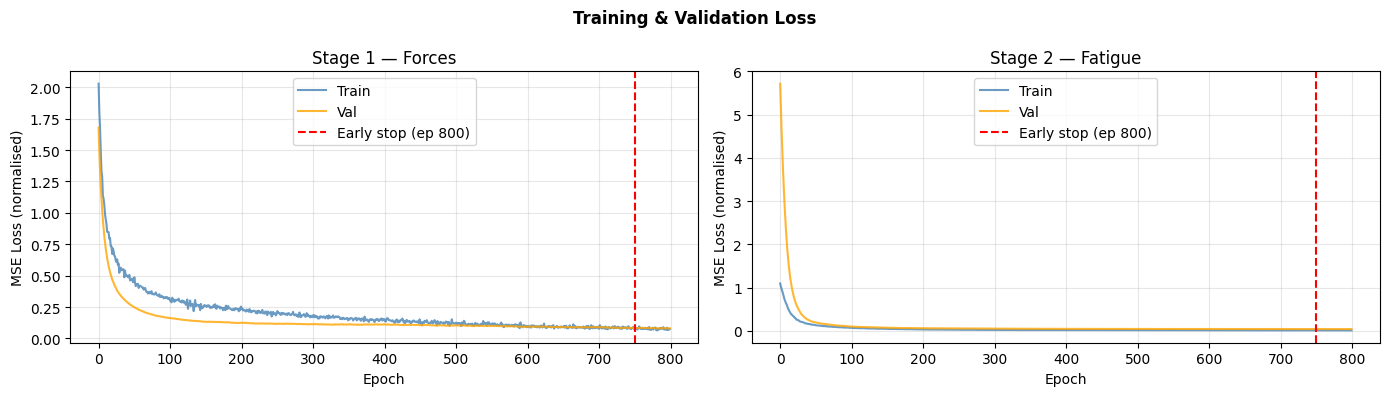

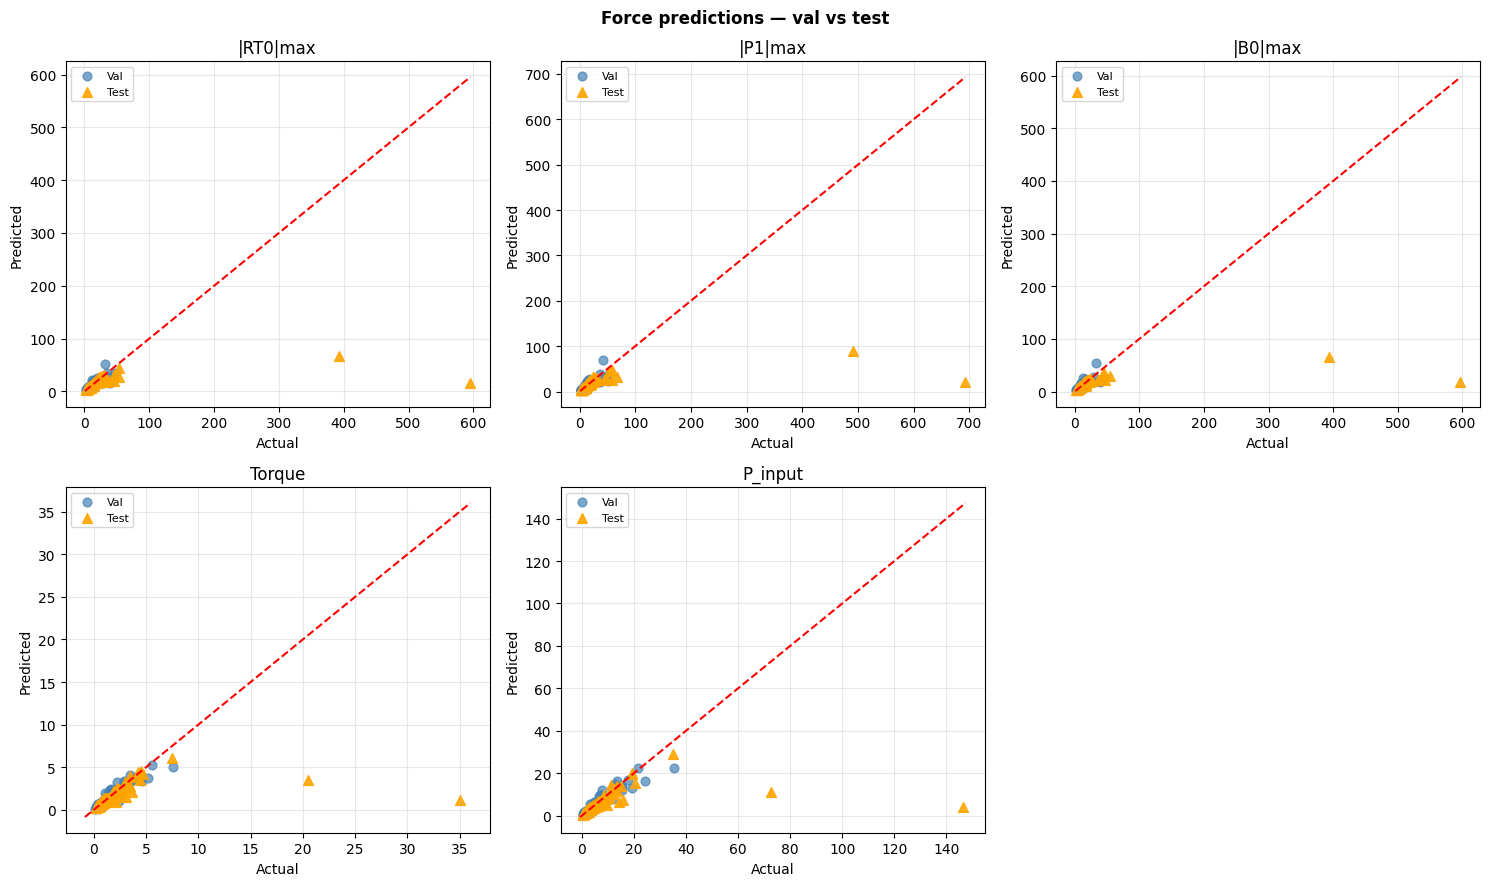

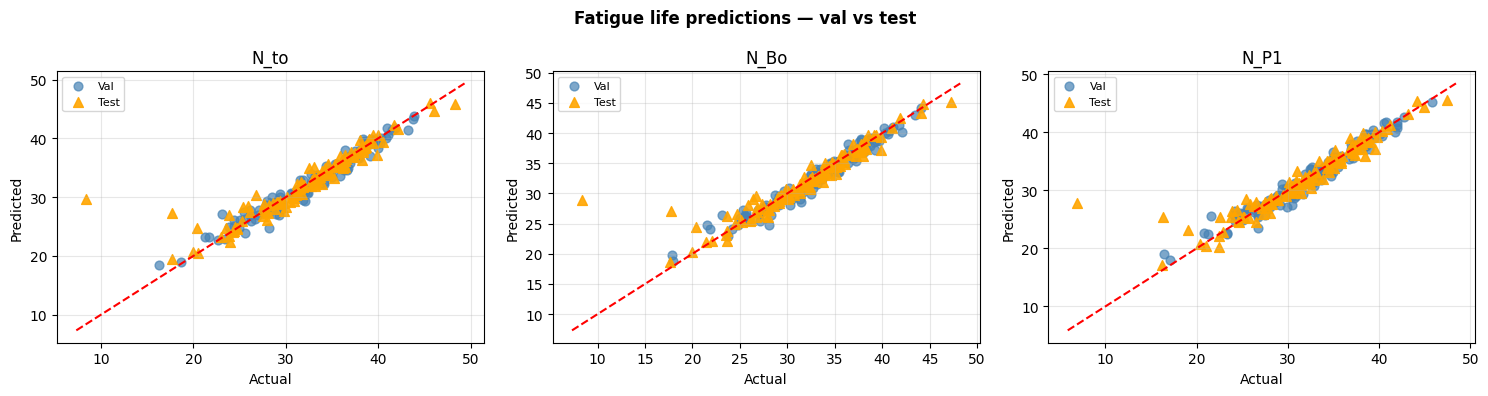

  Residuals
  -----------------------------------------------------------------
      Output |   Set |     Bias |      Std |  Max Err
  -----------------------------------------------------------------
  --- Forces ---
    |RT0|max |   Val |  -0.1469 |   3.9713 |  22.5625
    |RT0|max |  Test |  -8.3976 |  60.1530 | 577.7298
     |P1|max |   Val |  -0.2197 |   5.0026 |  27.9110
     |P1|max |  Test | -10.0099 |  70.8010 | 670.3681
     |B0|max |   Val |  -0.0742 |   4.3730 |  21.3970
     |B0|max |  Test |  -8.3469 |  60.1785 | 577.6973
      Torque |   Val |  -0.0299 |   0.4213 |   2.5724
      Torque |  Test |  -0.4914 |   3.4483 |  33.9108
     P_input |   Val |  -0.2019 |   1.8511 |  12.9098
     P_input |  Test |  -2.0563 |  14.0770 | 142.2807
  --- Fatigue ---
        N_to |   Val |  -0.2117 |   1.1522 |   3.9163
        N_to |  Test |  +0.2459 |   2.4007 |  21.3648
        N_Bo |   Val |  -0.2737 |   1.0885 |   3.2601
        N_Bo |  Test |  +0.1510 |   2.2921 |  20.5203
       

In [14]:
# ── Loss curve ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Training & Validation Loss', fontweight='bold')
for ax, train_h, val_h, stopped, title in [
    (axes[0], force_train_hist,   force_val_hist,   stopped_force,   'Stage 1 — Forces'),
    (axes[1], fatigue_train_hist, fatigue_val_hist, stopped_fatigue, 'Stage 2 — Fatigue'),
]:
    ax.plot(train_h, label='Train', color='steelblue', alpha=0.8)
    ax.plot(val_h,   label='Val',   color='orange',    alpha=0.8)
    ax.axvline(stopped - patience, color='red', linestyle='--', label=f'Early stop (ep {stopped})')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss (normalised)')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Force predictions scatter ──────────────────────────────────────────────────
n_f = len(force_cols)
fig, axes = plt.subplots(2, (n_f + 1) // 2, figsize=(5 * ((n_f + 1) // 2), 9))
fig.suptitle('Force predictions — val vs test', fontweight='bold')
axes = axes.flatten()
for i, col in enumerate(force_cols):
    ax = axes[i]
    ax.scatter(tf_val_w[:, i], pf_val_w[:, i], alpha=0.7, color='steelblue', s=40, label='Val')
    ax.scatter(tf_te_w[:,  i], pf_te_w[:,  i], alpha=0.9, color='orange',    s=50, label='Test', marker='^')
    lo = min(tf_val_w[:, i].min(), tf_te_w[:, i].min()) - 1
    hi = max(tf_val_w[:, i].max(), tf_te_w[:, i].max()) + 1
    ax.plot([lo, hi], [lo, hi], 'r--')
    ax.set_title(col); ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
for ax in axes[n_f:]: ax.set_visible(False)
plt.tight_layout()
plt.savefig('force_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Fatigue predictions scatter ────────────────────────────────────────────────
n_a = len(fatigue_cols)
fig, axes = plt.subplots(1, n_a, figsize=(5 * n_a, 4))
fig.suptitle('Fatigue life predictions — val vs test', fontweight='bold')
for i, col in enumerate(fatigue_cols):
    ax = axes[i]
    ax.scatter(ta_val_w[:, i], pa_val_w[:, i], alpha=0.7, color='steelblue', s=40, label='Val')
    ax.scatter(ta_te_w[:,  i], pa_te_w[:,  i], alpha=0.9, color='orange',    s=50, label='Test', marker='^')
    lo = min(ta_val_w[:, i].min(), ta_te_w[:, i].min()) - 1
    hi = max(ta_val_w[:, i].max(), ta_te_w[:, i].max()) + 1
    ax.plot([lo, hi], [lo, hi], 'r--')
    ax.set_title(col); ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fatigue_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Residual table ─────────────────────────────────────────────────────────────
print('  Residuals')
print('  ' + '-'*65)
print(f'  {"Output":>10} | {"Set":>5} | {"Bias":>8} | {"Std":>8} | {"Max Err":>8}')
print('  ' + '-'*65)
for group_name, cols, pv, tv, pt, tt in [
    ('Forces',  force_cols,   pf_val_w, tf_val_w, pf_te_w, tf_te_w),
    ('Fatigue', fatigue_cols, pa_val_w, ta_val_w, pa_te_w, ta_te_w),
]:
    print(f'  --- {group_name} ---')
    for i, col in enumerate(cols):
        for label, yp, yt in [('Val', pv, tv), ('Test', pt, tt)]:
            err = yp[:, i] - yt[:, i]
            print(f'  {col:>10} | {label:>5} | {err.mean():>+8.4f} | '
                  f'{err.std():>8.4f} | {np.abs(err).max():>8.4f}')
print('  ' + '-'*65)


In [15]:
print(f'\n  {"Output":>10} | {"Val MAE":>9} | {"Val R2":>8} | {"Test MAE":>9} | {"Test R2":>8}')
print(f'  {"-"*58}')
for col in force_cols:
    print(f'  {col:>10} | {val_force_res[col]["mae"]:>9.4f} | '
          f'{val_force_res[col]["r2"]:>8.4f} | '
          f'{test_force_res[col]["mae"]:>9.4f} | '
          f'{test_force_res[col]["r2"]:>8.4f}')


      Output |   Val MAE |   Val R2 |  Test MAE |  Test R2
  ----------------------------------------------------------
    |RT0|max |    2.0786 |   0.7709 |    9.4967 |   0.0895
     |P1|max |    2.5153 |   0.7116 |   11.4052 |   0.1130
     |B0|max |    2.1048 |   0.6523 |    9.3685 |   0.0917
      Torque |    0.2294 |   0.8785 |    0.6161 |   0.1071
     P_input |    0.9373 |   0.8765 |    2.4585 |   0.1083


In [16]:
# ══════════════════════════════════════════════════════════════════
#  Experiment Logger — paste after both stages finish
# ══════════════════════════════════════════════════════════════════

# ── Auto-read run number ─────────────────────────────────────────
log_file   = 'experiment_log.csv'
run_number = 0
if os.path.isfile(log_file):
    df_log     = pd.read_csv(log_file)
    run_number = len(df_log)

# ── Auto-detect config from models ───────────────────────────────
dropout_val = 0.0
for module in force_model.modules():
    if isinstance(module, nn.Dropout):
        dropout_val = module.p; break

norm_type = 'None'
for module in force_model.modules():
    if isinstance(module, nn.LayerNorm):
        norm_type = 'LayerNorm'; break
    elif isinstance(module, nn.BatchNorm1d):
        norm_type = 'BatchNorm1d'; break

has_skip = hasattr(force_model, 'skip')

hidden1_layers = [type(m).__name__ for m in force_model.hidden1]
hidden2_layers = [type(m).__name__ for m in force_model.hidden2]
force_arch = ' → '.join(hidden1_layers) + '  |  ' + ' → '.join(hidden2_layers)

fat_h1 = [type(m).__name__ for m in fatigue_model.hidden1]
fat_h2 = [type(m).__name__ for m in fatigue_model.hidden2]
fatigue_arch = ' → '.join(fat_h1) + '  |  ' + ' → '.join(fat_h2)

n_params_force   = sum(p.numel() for p in force_model.parameters())
n_params_fatigue = sum(p.numel() for p in fatigue_model.parameters())

# ── Hidden layer widths ──────────────────────────────────────────
force_widths   = ''
fatigue_widths = ''
for m in force_model.hidden1:
    if isinstance(m, nn.Linear):
        w1 = m.out_features; break
for m in force_model.hidden2:
    if isinstance(m, nn.Linear):
        w2 = m.out_features; break
force_widths = f'{w1} → {w2}'

for m in fatigue_model.hidden1:
    if isinstance(m, nn.Linear):
        fw1 = m.out_features; break
for m in fatigue_model.hidden2:
    if isinstance(m, nn.Linear):
        fw2 = m.out_features; break
fatigue_widths = f'{fw1} → {fw2}'
if has_skip:
    force_widths   += ' + skip'
    fatigue_widths += ' + skip'

# ── Build config dict ────────────────────────────────────────────
run_config = {
    'run_number'       : run_number + 1,
    'timestamp'        : datetime.now().strftime('%Y-%m-%d %H:%M'),
    'split_method'     : 'stratified',          # ← update when you change it
    'loss_force'       : type(nn.HuberLoss()).__name__,   # ← match your criterion
    'loss_fatigue'     : 'FatigueLoss',                   # ← match your criterion
    'hidden_force'     : force_widths,
    'hidden_fatigue'   : fatigue_widths,
    'force_arch'       : force_arch,
    'fatigue_arch'     : fatigue_arch,
    'norm_type'        : norm_type,
    'skip_connection'  : has_skip,
    'n_params_force'   : n_params_force,
    'n_params_fatigue' : n_params_fatigue,
    'optimizer'        : type(optimizer_force).__name__,
    'lr'               : optimizer_force.param_groups[0]['lr'],
    'weight_decay'     : optimizer_force.param_groups[0].get('weight_decay', 0),
    'dropout'          : dropout_val,
    'epochs_max'       : epochs,
    'stopped_force'    : stopped_force,
    'stopped_fatigue'  : stopped_fatigue,
    'best_force_val'   : round(best_force_val, 6),
    'best_fatigue_val' : round(best_fatigue_val, 6),
    'patience'         : patience,
    'batch_size'       : batch_size,
    'n_force_outputs'  : n_force,
    'n_fatigue_outputs': n_fatigue,
    'seed'             : seed,
    'n_total'          : len(x),
    'n_train'          : len(train_idx),
    'n_val'            : len(val_idx),
    'n_test'           : len(test_idx),
    'pct_train'        : round(len(train_idx)/len(x)*100, 1),
    'pct_val'          : round(len(val_idx)/len(x)*100,   1),
    'pct_test'         : round(len(test_idx)/len(x)*100,  1),
    'notes'            : '',                     # ← add notes per run
}

# ── Collect metrics ──────────────────────────────────────────────
run_metrics = {}
for col in force_cols:
    for split, res in [('val', val_force_res), ('test', test_force_res)]:
        run_metrics[f'{col}_{split}_mae']  = round(res[col]['mae'],  4)
        run_metrics[f'{col}_{split}_rmse'] = round(res[col]['rmse'], 4)
        run_metrics[f'{col}_{split}_mse']  = round(res[col]['rmse']**2, 4)
        run_metrics[f'{col}_{split}_r2']   = round(res[col]['r2'],   4)

for col in fatigue_cols:
    for split, res in [('val', val_fat_res), ('test', test_fat_res)]:
        run_metrics[f'{col}_{split}_mae']  = round(res[col]['mae'],  4)
        run_metrics[f'{col}_{split}_rmse'] = round(res[col]['rmse'], 4)
        run_metrics[f'{col}_{split}_mse']  = round(res[col]['rmse']**2, 4)
        run_metrics[f'{col}_{split}_r2']   = round(res[col]['r2'],   4)

# ── Mean summaries ───────────────────────────────────────────────
for split in ['val', 'test']:
    force_r2s  = [run_metrics[f'{c}_{split}_r2']  for c in force_cols]
    force_maes = [run_metrics[f'{c}_{split}_mae'] for c in force_cols]
    fat_r2s    = [run_metrics[f'{c}_{split}_r2']  for c in fatigue_cols]
    fat_maes   = [run_metrics[f'{c}_{split}_mae'] for c in fatigue_cols]

    run_metrics[f'force_mean_{split}_r2']   = round(np.mean(force_r2s),  4)
    run_metrics[f'force_mean_{split}_mae']  = round(np.mean(force_maes), 4)
    run_metrics[f'fatigue_mean_{split}_r2'] = round(np.mean(fat_r2s),    4)
    run_metrics[f'fatigue_mean_{split}_mae']= round(np.mean(fat_maes),   4)

# ── Write to CSV (handles new columns across runs) ───────────────
row = {**run_config, **run_metrics}

if os.path.isfile(log_file):
    existing = pd.read_csv(log_file)
    new_row  = pd.DataFrame([row])
    combined = pd.concat([existing, new_row], ignore_index=True)
else:
    combined = pd.DataFrame([row])

combined.to_csv(log_file, index=False)

# ── Summary print ────────────────────────────────────────────────
print('=' * 70)
print(f'  Run {run_config["run_number"]} logged → {log_file}')
print('=' * 70)
print(f'  Split         : {run_config["split_method"]}  '
      f'({run_config["pct_train"]}/{run_config["pct_val"]}/{run_config["pct_test"]}%)')
print(f'  Loss          : force={run_config["loss_force"]}  '
      f'fatigue={run_config["loss_fatigue"]}')
print(f'  Force arch    : {force_widths}  ({n_params_force:,} params)')
print(f'  Fatigue arch  : {fatigue_widths}  ({n_params_fatigue:,} params)')
print(f'  Norm          : {norm_type}   Skip: {has_skip}')
print(f'  Optimizer     : {run_config["optimizer"]}  lr={run_config["lr"]}  '
      f'wd={run_config["weight_decay"]}')
print(f'  Dropout       : {dropout_val}')
print(f'  Stopped       : force={stopped_force}  fatigue={stopped_fatigue}  / {epochs}')
print(f'  Best val loss : force={best_force_val:.6f}  '
      f'fatigue={best_fatigue_val:.6f}')
print('-' * 70)
print(f'  {"Output":>12} | {"Val MAE":>8} | {"Val RMSE":>9} | {"Val R²":>7} | '
      f'{"Test MAE":>9} | {"Test RMSE":>10} | {"Test R²":>8}')
print(f'  {"-"*68}')
print(f'  --- Forces ---')
for col in force_cols:
    print(f'  {col:>12} | '
          f'{run_metrics[f"{col}_val_mae"]:>8.4f} | '
          f'{run_metrics[f"{col}_val_rmse"]:>9.4f} | '
          f'{run_metrics[f"{col}_val_r2"]:>7.4f} | '
          f'{run_metrics[f"{col}_test_mae"]:>9.4f} | '
          f'{run_metrics[f"{col}_test_rmse"]:>10.4f} | '
          f'{run_metrics[f"{col}_test_r2"]:>8.4f}')
print(f'  {"MEAN":>12} | '
      f'{run_metrics["force_mean_val_mae"]:>8.4f} | {"":>9} | '
      f'{run_metrics["force_mean_val_r2"]:>7.4f} | '
      f'{run_metrics["force_mean_test_mae"]:>9.4f} | {"":>10} | '
      f'{run_metrics["force_mean_test_r2"]:>8.4f}')
print(f'  --- Fatigue ---')
for col in fatigue_cols:
    print(f'  {col:>12} | '
          f'{run_metrics[f"{col}_val_mae"]:>8.4f} | '
          f'{run_metrics[f"{col}_val_rmse"]:>9.4f} | '
          f'{run_metrics[f"{col}_val_r2"]:>7.4f} | '
          f'{run_metrics[f"{col}_test_mae"]:>9.4f} | '
          f'{run_metrics[f"{col}_test_rmse"]:>10.4f} | '
          f'{run_metrics[f"{col}_test_r2"]:>8.4f}')
print(f'  {"MEAN":>12} | '
      f'{run_metrics["fatigue_mean_val_mae"]:>8.4f} | {"":>9} | '
      f'{run_metrics["fatigue_mean_val_r2"]:>7.4f} | '
      f'{run_metrics["fatigue_mean_test_mae"]:>9.4f} | {"":>10} | '
      f'{run_metrics["fatigue_mean_test_r2"]:>8.4f}')
print('=' * 70)

  Run 1 logged → experiment_log.csv
  Split         : stratified  (70.0/14.9/15.1%)
  Loss          : force=HuberLoss  fatigue=FatigueLoss
  Force arch    : 64 → 128  (10,181 params)
  Fatigue arch  : 32 → 64  (4,227 params)
  Norm          : LayerNorm   Skip: False
  Optimizer     : AdamW  lr=0.0001  wd=0.005
  Dropout       : 0.1
  Stopped       : force=800  fatigue=800  / 800
  Best val loss : force=0.080175  fatigue=0.039655
----------------------------------------------------------------------
        Output |  Val MAE |  Val RMSE |  Val R² |  Test MAE |  Test RMSE |  Test R²
  --------------------------------------------------------------------
  --- Forces ---
      |RT0|max |   2.0786 |    3.9740 |  0.7709 |    9.4967 |    60.7363 |   0.0895
       |P1|max |   2.5153 |    5.0075 |  0.7116 |   11.4052 |    71.5051 |   0.1130
       |B0|max |   2.1048 |    4.3737 |  0.6523 |    9.3685 |    60.7546 |   0.0917
        Torque |   0.2294 |    0.4224 |  0.8785 |    0.6161 |     3.4831

Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  Computing SHAP for ForceNet...


  0%|          | 0/100 [00:00<?, ?it/s]

  X_explain.shape:  (100, 12)
  Force outputs:    5
  Per-output shape: (100, 12)


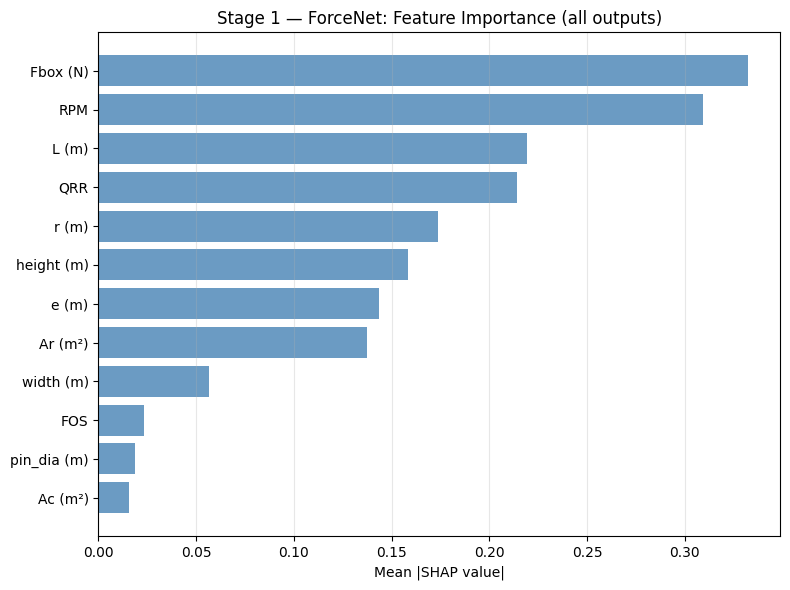

  SHAP beeswarm: |RT0|max


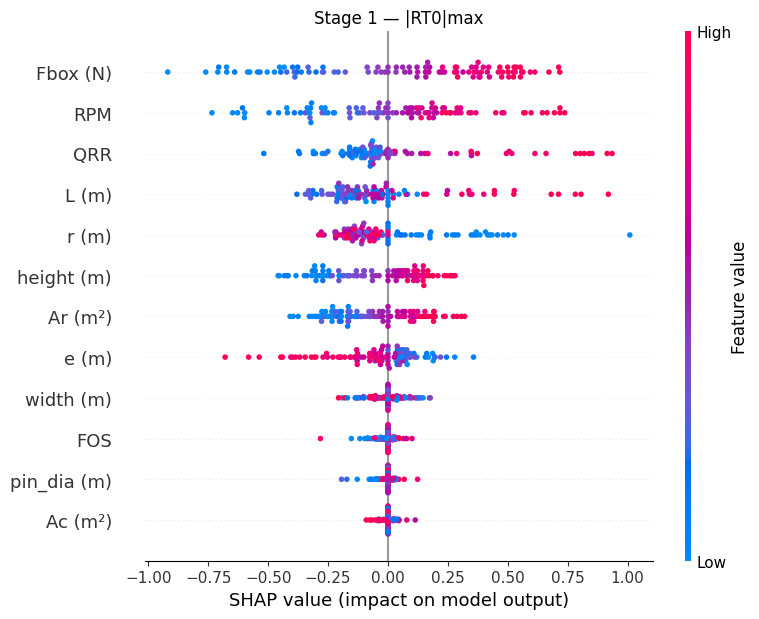

  SHAP beeswarm: |P1|max


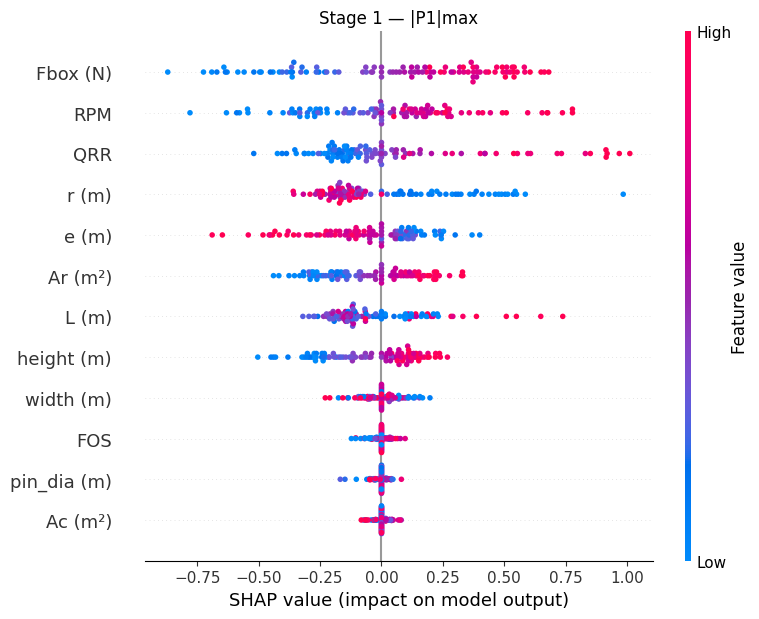

  SHAP beeswarm: |B0|max


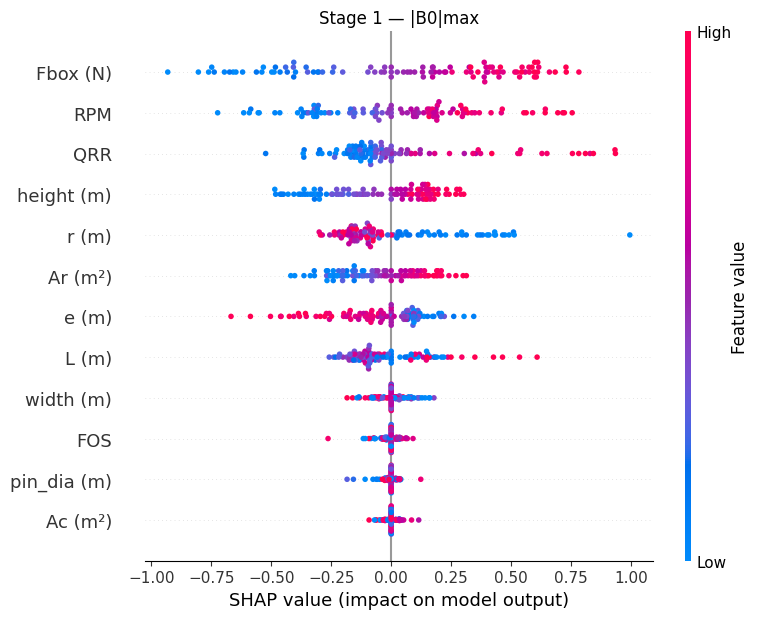

  SHAP beeswarm: Torque


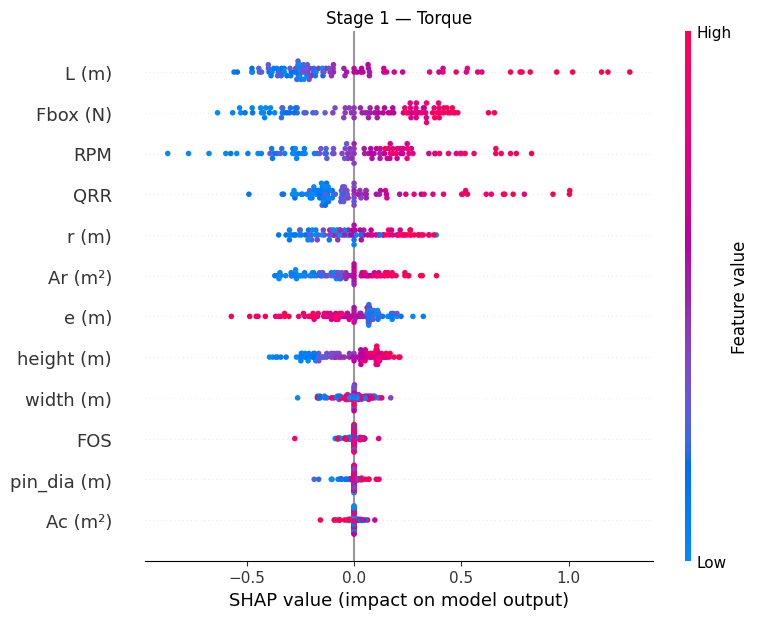

  SHAP beeswarm: P_input


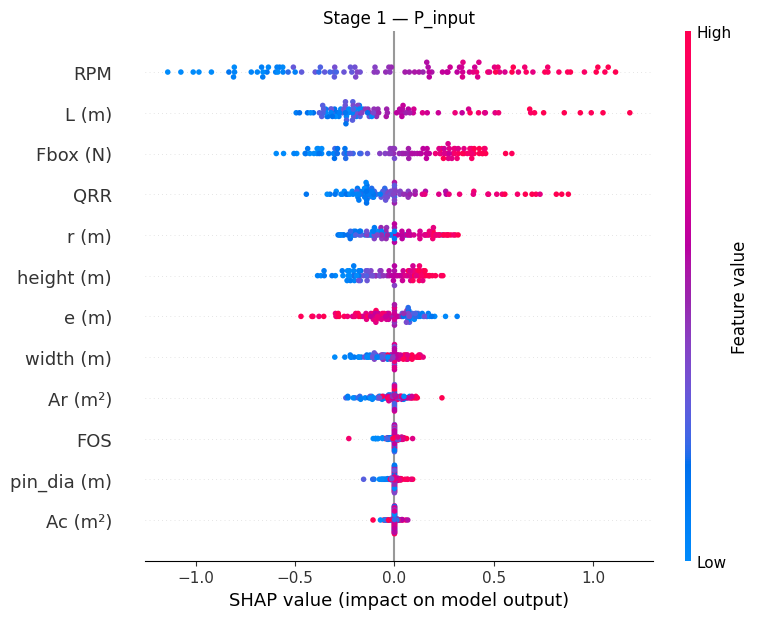

Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  Computing SHAP for FatigueNet (cascade)...


  0%|          | 0/100 [00:00<?, ?it/s]

  Fatigue outputs:    3
  Per-output shape:   (100, 12)


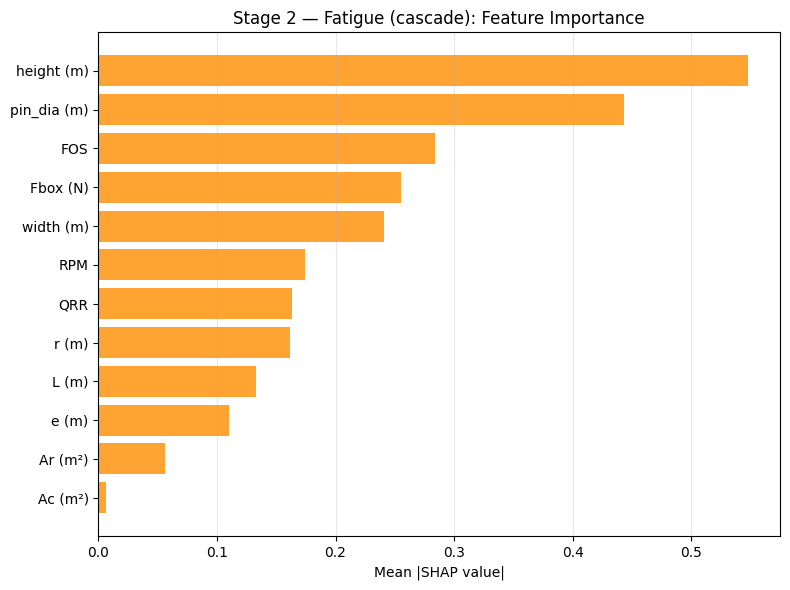

  SHAP beeswarm: N_to


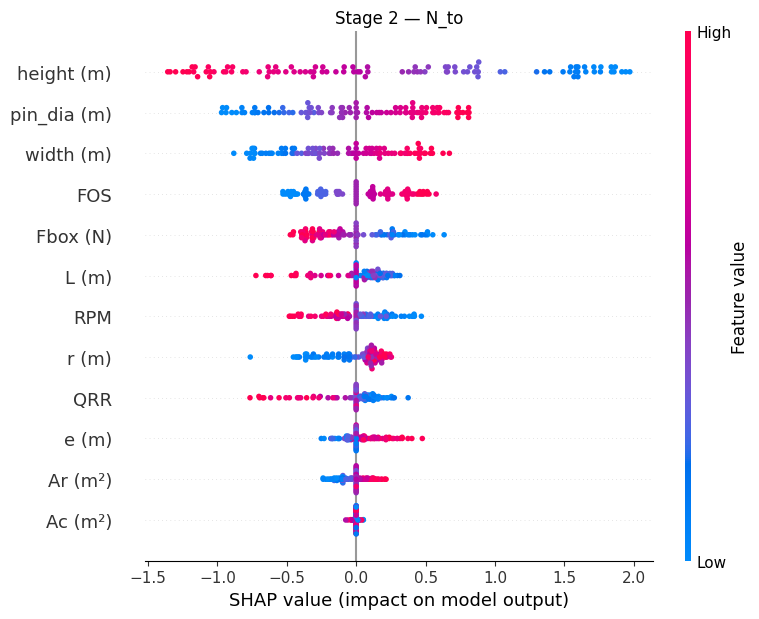

  SHAP beeswarm: N_Bo


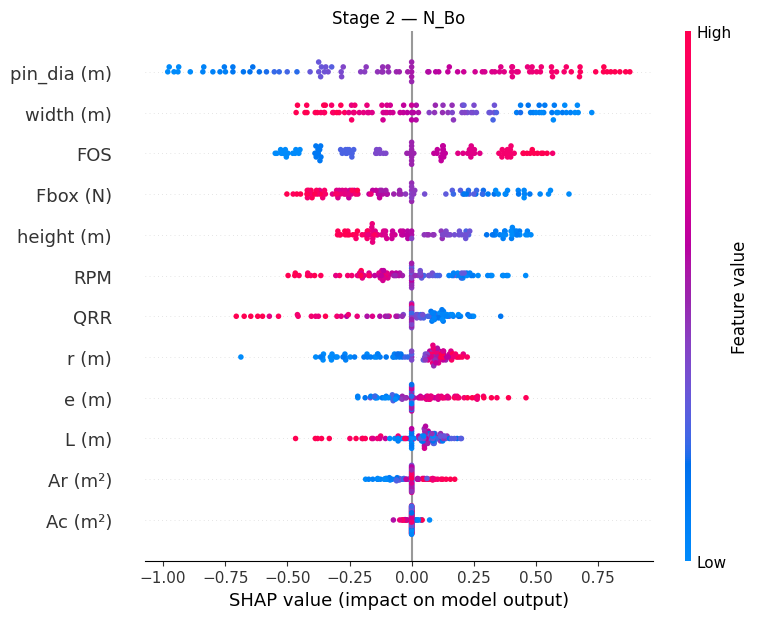

  SHAP beeswarm: N_P1


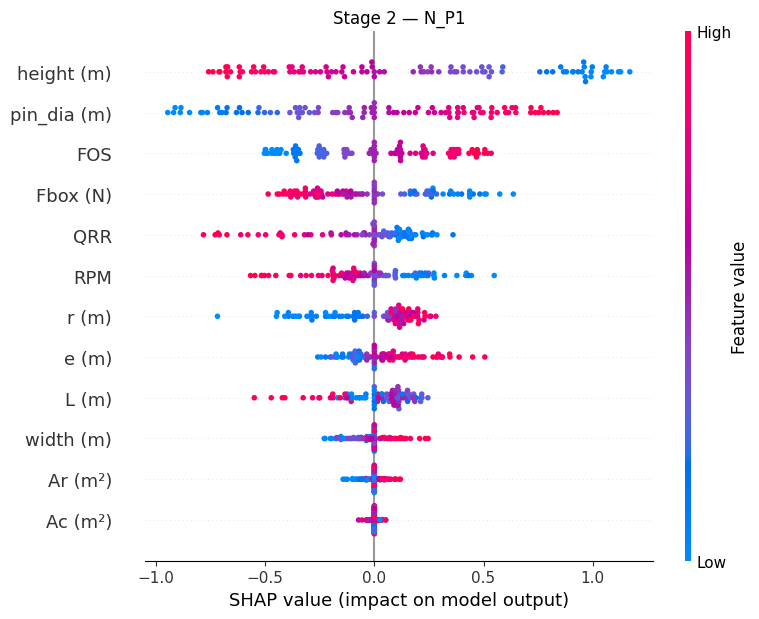


  Top Features by Mean |SHAP|
  Rank |          Force Model |   Fatigue Model (cascade)
  --------------------------------------------------------
     1 |        Fbox (N) 0.3321 |      height (m) 0.5474
     2 |             RPM 0.3092 |     pin_dia (m) 0.4433
     3 |           L (m) 0.2194 |             FOS 0.2834
     4 |             QRR 0.2140 |        Fbox (N) 0.2550
     5 |           r (m) 0.1735 |       width (m) 0.2406
     6 |      height (m) 0.1583 |             RPM 0.1740
     7 |           e (m) 0.1436 |             QRR 0.1631
     8 |         Ar (m²) 0.1373 |           r (m) 0.1620
     9 |       width (m) 0.0566 |           L (m) 0.1328
    10 |             FOS 0.0232 |           e (m) 0.1100


In [17]:
# ══════════════════════════════════════════════════════════════════
#  SHAP Analysis — paste as a new cell after evaluation
# ══════════════════════════════════════════════════════════════════

import shap

# ── Wrapper functions (SHAP needs numpy in → numpy out) ──────────

class ForceWrapper:
    """Wraps force_model for SHAP: numpy → numpy."""
    def __init__(self, model, device):
        self.model  = model
        self.device = device
        self.model.eval()

    def __call__(self, X):
        with torch.no_grad():
            t = torch.tensor(X, dtype=torch.float32).to(self.device)
            return self.model(t).cpu().numpy()


class FatigueWrapper:
    """Wraps the full cascade (force → fatigue) for SHAP."""
    def __init__(self, force_model, fatigue_model, device):
        self.force_model   = force_model
        self.fatigue_model = fatigue_model
        self.device        = device
        self.force_model.eval()
        self.fatigue_model.eval()

    def __call__(self, X):
        with torch.no_grad():
            t = torch.tensor(X, dtype=torch.float32).to(self.device)
            pred_f = self.force_model(t)
            pred_a = self.fatigue_model(t, pred_f)
            return pred_a.cpu().numpy()


# ── Background data (use training set, subsample for speed) ──────

n_background = min(200, len(x_tr_norm))
bg_idx       = np.random.choice(len(x_tr_norm), n_background, replace=False)
background   = x_tr_norm[bg_idx].numpy()


# ── Helper: normalise shap_values into (n_outputs, n_samples, n_features) ──

def normalise_shap(sv):
    """
    Accepts either:
      - list of arrays, each (n_samples, n_features)         → old SHAP
      - 3-D array (n_samples, n_features, n_outputs)         → new SHAP
      - 2-D array (n_samples, n_features)  [single output]
    Returns: list of 2-D arrays, one per output.
    """
    if isinstance(sv, list):
        return sv
    if sv.ndim == 3:
        # (n_samples, n_features, n_outputs) → list of (n_samples, n_features)
        return [sv[:, :, i] for i in range(sv.shape[2])]
    # single output
    return [sv]


# ── Feature names ────────────────────────────────────────────────

n_model_features = background.shape[1]
if len(feature_cols) == n_model_features:
    shap_feature_names = list(feature_cols)
else:
    print(f'  ⚠ feature_cols has {len(feature_cols)} entries but model '
          f'has {n_model_features} inputs — using generic names')
    shap_feature_names = [f'Feature {i}' for i in range(n_model_features)]


# ══════════════════════════════════════════════════════════════════
#  Stage 1: Force SHAP
# ══════════════════════════════════════════════════════════════════

print('  Computing SHAP for ForceNet...')

force_fn        = ForceWrapper(force_model, device)
force_explainer = shap.KernelExplainer(force_fn, background)

n_explain   = min(100, len(x_te_norm))
explain_idx = np.random.choice(len(x_te_norm), n_explain, replace=False)
X_explain   = x_te_norm[explain_idx].numpy()

force_shap_raw    = force_explainer.shap_values(X_explain)
force_shap_list   = normalise_shap(force_shap_raw)   # list of (n_samples, n_features)
n_force_outputs   = len(force_shap_list)

print(f'  X_explain.shape:  {X_explain.shape}')
print(f'  Force outputs:    {n_force_outputs}')
print(f'  Per-output shape: {force_shap_list[0].shape}')

# ── Summary bar plot: mean |SHAP| across all force outputs ──────

mean_abs_shap = np.mean(
    np.stack([np.mean(np.abs(sv), axis=0) for sv in force_shap_list], axis=0),
    axis=0,
)  # (n_features,)

top_k      = min(15, len(mean_abs_shap))
sorted_idx = np.argsort(mean_abs_shap)[::-1]
top_idx    = sorted_idx[:top_k]

fig, ax = plt.subplots(figsize=(8, 6))
vals = mean_abs_shap[top_idx][::-1]
ax.barh(range(len(vals)), vals, color='steelblue', alpha=0.8)
ax.set_yticks(range(len(vals)))
ax.set_yticklabels([shap_feature_names[i] for i in top_idx][::-1])
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Stage 1 — ForceNet: Feature Importance (all outputs)')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('shap_force_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Detailed beeswarm per force output ───────────────────────────

for i, col in enumerate(force_cols):
    if i >= n_force_outputs:
        break
    print(f'  SHAP beeswarm: {col}')
    shap.summary_plot(
        force_shap_list[i],
        X_explain,
        feature_names=shap_feature_names,
        plot_type='dot',
        max_display=15,
        show=False,
    )
    plt.title(f'Stage 1 — {col}')
    plt.tight_layout()
    plt.savefig(f'shap_force_{col.replace("|","").replace(" ","_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()


# ══════════════════════════════════════════════════════════════════
#  Stage 2: Fatigue SHAP (full cascade)
# ══════════════════════════════════════════════════════════════════

print('  Computing SHAP for FatigueNet (cascade)...')

fatigue_fn        = FatigueWrapper(force_model, fatigue_model, device)
fatigue_explainer = shap.KernelExplainer(fatigue_fn, background)

fatigue_shap_raw  = fatigue_explainer.shap_values(X_explain)
fatigue_shap_list = normalise_shap(fatigue_shap_raw)
n_fat_outputs     = len(fatigue_shap_list)

print(f'  Fatigue outputs:    {n_fat_outputs}')
print(f'  Per-output shape:   {fatigue_shap_list[0].shape}')

# ── Summary bar plot ─────────────────────────────────────────────

mean_abs_fat = np.mean(
    np.stack([np.mean(np.abs(sv), axis=0) for sv in fatigue_shap_list], axis=0),
    axis=0,
)

top_k_fat    = min(15, len(mean_abs_fat))
sorted_idx_f = np.argsort(mean_abs_fat)[::-1]
top_idx_f    = sorted_idx_f[:top_k_fat]

fig, ax = plt.subplots(figsize=(8, 6))
vals_f = mean_abs_fat[top_idx_f][::-1]
ax.barh(range(len(vals_f)), vals_f, color='darkorange', alpha=0.8)
ax.set_yticks(range(len(vals_f)))
ax.set_yticklabels([shap_feature_names[i] for i in top_idx_f][::-1])
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Stage 2 — Fatigue (cascade): Feature Importance')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('shap_fatigue_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Detailed beeswarm per fatigue output ─────────────────────────

for i, col in enumerate(fatigue_cols):
    if i >= n_fat_outputs:
        break
    print(f'  SHAP beeswarm: {col}')
    shap.summary_plot(
        fatigue_shap_list[i],
        X_explain,
        feature_names=shap_feature_names,
        plot_type='dot',
        max_display=15,
        show=False,
    )
    plt.title(f'Stage 2 — {col}')
    plt.tight_layout()
    plt.savefig(f'shap_fatigue_{col}.png', dpi=150, bbox_inches='tight')
    plt.show()


# ══════════════════════════════════════════════════════════════════
#  Print top features table
# ══════════════════════════════════════════════════════════════════

top_table = min(10, top_k, top_k_fat)

print('\n' + '=' * 60)
print('  Top Features by Mean |SHAP|')
print('=' * 60)
print(f'  {"Rank":>4} | {"Force Model":>20} | {"Fatigue Model (cascade)":>25}')
print(f'  {"-"*56}')
for rank in range(top_table):
    f_name = shap_feature_names[sorted_idx[rank]]
    f_val  = mean_abs_shap[sorted_idx[rank]]
    a_name = shap_feature_names[sorted_idx_f[rank]]
    a_val  = mean_abs_fat[sorted_idx_f[rank]]
    print(f'  {rank+1:>4} | {f_name:>15} {f_val:.4f} | '
          f'{a_name:>15} {a_val:.4f}')
print('=' * 60)

In [18]:
print(f'X_explain.shape: {X_explain.shape}')
print(f'type(force_shap_values): {type(force_shap_values)}')
if isinstance(force_shap_values, list):
    print(f'len(force_shap_values): {len(force_shap_values)}')
    for i, sv in enumerate(force_shap_values):
        print(f'  force_shap_values[{i}].shape: {sv.shape}')
elif isinstance(force_shap_values, np.ndarray):
    print(f'force_shap_values.shape: {force_shap_values.shape}')

X_explain.shape: (100, 12)


NameError: name 'force_shap_values' is not defined